In [75]:
###import necessary libraries
# eda
import pandas as pd
import numpy as np

df = pd.read_csv("Water Quality Prediction.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 24 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   Index                   1048575 non-null  int64  
 1   pH                      1028344 non-null  float64
 2   Iron                    1041584 non-null  float64
 3   Nitrate                 1029880 non-null  float64
 4   Chloride                1017741 non-null  float64
 5   Lead                    1043891 non-null  float64
 6   Zinc                    1020900 non-null  float64
 7   Color                   1047594 non-null  object 
 8   Turbidity               1039881 non-null  float64
 9   Fluoride                1015357 non-null  float64
 10  Copper                  1013693 non-null  float64
 11  Odor                    1017243 non-null  float64
 12  Sulfate                 1014050 non-null  float64
 13  Conductivity            1019772 non-null  float64
 14  Ch

In [77]:
(df.isnull().sum()/len(df))*100

Index                     0.000000
pH                        1.929380
Iron                      0.666714
Nitrate                   1.782896
Chloride                  2.940562
Lead                      0.446701
Zinc                      2.639296
Color                     0.093556
Turbidity                 0.829125
Fluoride                  3.167918
Copper                    3.326610
Odor                      2.988055
Sulfate                   3.292564
Conductivity              2.746871
Chlorine                  0.969125
Manganese                 1.844313
Total Dissolved Solids    0.028420
Source                    1.481534
Water Temperature         2.831271
Air Temperature           0.505734
Month                     1.613714
Day                       1.673605
Time of Day               1.941778
Target                    0.000000
dtype: float64

In [78]:
# drop unwanted columns
df.drop(columns=['Index', 'Color', 'Source', 'Month', 'Day', 'Time of Day'], inplace=True)

In [79]:
# Remove duplicates
df = df.drop_duplicates()

In [80]:
(df.isnull().sum()/len(df))*100

pH                        1.960294
Iron                      0.677631
Nitrate                   1.811702
Chloride                  2.986870
Lead                      0.454016
Zinc                      2.681446
Turbidity                 0.842605
Fluoride                  3.218143
Copper                    3.379724
Odor                      3.034850
Sulfate                   3.345120
Conductivity              2.790395
Chlorine                  0.984897
Manganese                 1.874027
Total Dissolved Solids    0.028885
Water Temperature         2.877243
Air Temperature           0.513918
Target                    0.000000
dtype: float64

In [86]:
# Fill missing values with median for all numerical columns
for col in df.select_dtypes(include=["int64", "float64"]).columns:
    median_val = df[col].median()
    df.fillna({col : median_val}, inplace=True)

In [87]:
(df.isnull().sum()/len(df))*100

pH                        0.0
Iron                      0.0
Nitrate                   0.0
Chloride                  0.0
Lead                      0.0
Zinc                      0.0
Turbidity                 0.0
Fluoride                  0.0
Copper                    0.0
Odor                      0.0
Sulfate                   0.0
Conductivity              0.0
Chlorine                  0.0
Manganese                 0.0
Total Dissolved Solids    0.0
Water Temperature         0.0
Air Temperature           0.0
Target                    0.0
dtype: float64

In [90]:
# Detect and Cap Extreme Values in Each Column (except Target)
def cap_outliers(df):
    df_capped = df.copy()
    
    # List of numeric columns, excluding 'Target'
    num_cols = [col for col in df.select_dtypes(include='number').columns if col != "Target"]

    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df_capped[col] = df[col].clip(lower, upper)  # Cap values only in features

    return df_capped


In [92]:
# Apply it
df_capped = cap_outliers(df)
print("Shape after capping:", df_capped.shape)


# # Check if outliers remain (excluding 'Target')
# detect_outlier_counts(df_capped.drop(columns='Target'))

Shape after capping: (1031682, 18)


In [94]:
(df_capped.isnull().sum()/len(df))*100

pH                        0.0
Iron                      0.0
Nitrate                   0.0
Chloride                  0.0
Lead                      0.0
Zinc                      0.0
Turbidity                 0.0
Fluoride                  0.0
Copper                    0.0
Odor                      0.0
Sulfate                   0.0
Conductivity              0.0
Chlorine                  0.0
Manganese                 0.0
Total Dissolved Solids    0.0
Water Temperature         0.0
Air Temperature           0.0
Target                    0.0
dtype: float64

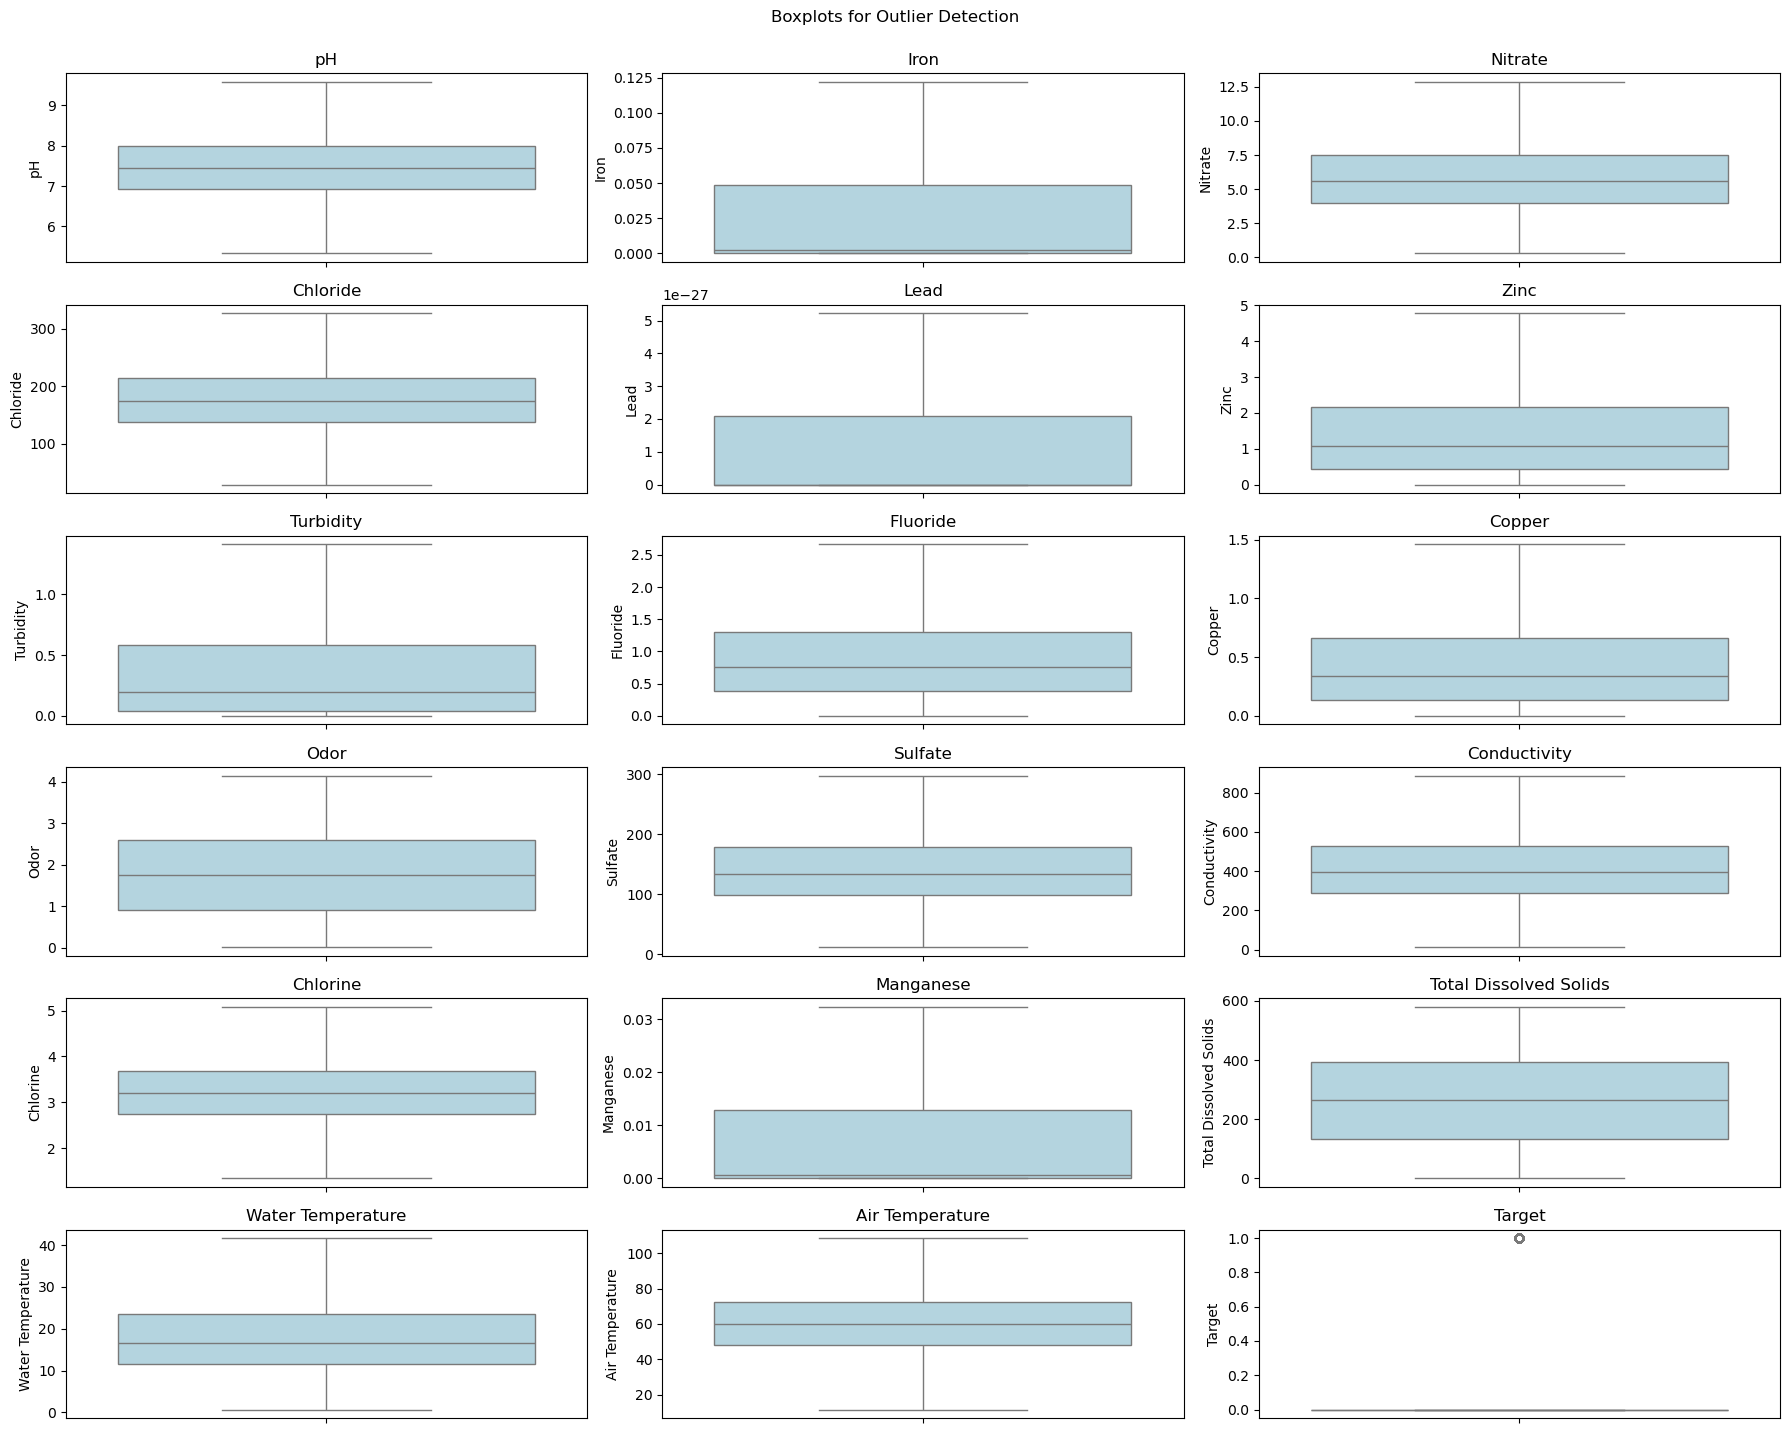

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df_capped.select_dtypes(include='number').columns.tolist()
plt.figure(figsize=(18, 14))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(6, 3, i)
    sns.boxplot(y=df_capped[col], color='lightblue')
    plt.title(col)

plt.tight_layout()
plt.suptitle("Boxplots for Outlier Detection", y=1.02)
plt.show()

In [97]:
df_capped.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1031682 entries, 0 to 1048574
Data columns (total 18 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   pH                      1031682 non-null  float64
 1   Iron                    1031682 non-null  float64
 2   Nitrate                 1031682 non-null  float64
 3   Chloride                1031682 non-null  float64
 4   Lead                    1031682 non-null  float64
 5   Zinc                    1031682 non-null  float64
 6   Turbidity               1031682 non-null  float64
 7   Fluoride                1031682 non-null  float64
 8   Copper                  1031682 non-null  float64
 9   Odor                    1031682 non-null  float64
 10  Sulfate                 1031682 non-null  float64
 11  Conductivity            1031682 non-null  float64
 12  Chlorine                1031682 non-null  float64
 13  Manganese               1031682 non-null  float64
 14  Total D

In [98]:
df_capped.to_csv("Water_quality_cleaned.csv", index=False)

In [99]:
df1= pd.read_csv("Water_quality_outliers_capped.csv")

In [100]:
# Check class distribution
class_counts = df1["Target"].value_counts()
print(class_counts)

# Calculate imbalance ratio
ratio = class_counts.max() / class_counts.min()
print(f"Ratio: {ratio:.1f}:1")

Target
0    807841
1    240734
Name: count, dtype: int64
Ratio: 3.4:1


In [103]:
import sklearn
# target
y=df1["Target"]

x= df1[[ 'pH', 'Iron', 'Nitrate', 'Chloride', 'Lead', 'Zinc',
    'Turbidity', 'Fluoride', 'Copper', 'Odor', 'Sulfate',
    'Conductivity', 'Chlorine', 'Manganese',
    'Total Dissolved Solids', 'Water Temperature', 'Air Temperature']]

# feature extraction 
numerical_cols = x.select_dtypes( include=["int64","float64"] ).columns.tolist()

# preprocessing
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
numerical_pl = Pipeline( steps = [ ("scaler",RobustScaler()) ])


# Columntransformer
from sklearn.compose import ColumnTransformer
ct = ColumnTransformer(transformers =[("scaler",numerical_pl,[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16])])

# splitting data 
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test =train_test_split(x,y ,test_size =0.25 ,random_state= 23)

# final pipeline for algorithm
from sklearn.naive_bayes import GaussianNB 
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from imblearn.pipeline import Pipeline as ImbPipeline  # Use imbalanced-learn pipeline

final_pl = ImbPipeline(steps=[
    ("columntrans", ct),("smote", SMOTE(random_state=42)),
    ("algorithm", GaussianNB(var_smoothing= 6.135506425409834e-06))
])

                                        
# fit 
final_pl.fit(x_train,y_train)

# # predict 
y_pred = final_pl.predict(x_test)

# score 
from sklearn.metrics import accuracy_score , classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))
# print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8242073059082031


In [104]:
# pickleing
import pickle

with open("Water Quality Prediction.pickle","wb") as f:  # write 
    pickle.dump(final_pl,f)

with open("Water Quality Prediction.pickle","rb") as f: # read 
    model = pickle.load(f)


In [105]:
model.predict([[4.428195	,3.524895e-03,	2.659169,	153.845260,	5.600000e-14	,0.912130,	2.480747e-01,	1.051271	,0.000216,	0.407678	,162.245960	,420.993474	,3.791842	,1.440000e-06	,1.665096	,7.511176,	62.295507]])

C:\Users\schai\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(


array([1], dtype=int64)

In [173]:
# import pandas as pd
# from sklearn.model_selection import train_test_split, RandomizedSearchCV  # Faster than GridSearch
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import RobustScaler
# from sklearn.compose import ColumnTransformer
# from sklearn.naive_bayes import GaussianNB
# from sklearn.metrics import classification_report, confusion_matrix
# from imblearn.over_sampling import SMOTE
# from imblearn.pipeline import make_pipeline
# from scipy.stats import loguniform  # For sampling hyperparameters

# # --- Load & Prep Data (Same as Before) ---
# y = df["Target"]
# x = df.drop("Target", axis=1)

# # --- Faster Preprocessing ---
# # Use ColumnTransformer directly (no nested pipeline)
# preprocessor = ColumnTransformer(
#     transformers=[("num", RobustScaler(), numerical_cols)],
#     remainder="passthrough"
# )

# # --- Simplified Pipeline (No SMOTE for GridSearch) ---
# # Note: SMOTE slows down GridSearch drastically. We'll handle imbalance separately.
# pipeline = make_pipeline(
#     preprocessor,
#     GaussianNB()
# )

# # --- RandomizedSearchCV (Faster than GridSearch) ---
# clean_params = {k.replace('gaussiannb__', ''): v for k, v in best_params.items()}

# # Focus on minority class (use F1-score)
# scorer = make_scorer(f1_score, average='weighted')  

# # Reduce CV folds to 3 (for speed)
# search = RandomizedSearchCV(
#     pipeline,
#     param_distributions=params,
#     n_iter=5,  # Test only 5 combinations (adjust as needed)
#     scoring=scorer,
#     cv=3,       # Fewer folds = faster
#     n_jobs=-1,  # Parallelize
#     random_state=23,
#     verbose=1
# )

# # --- Train on a Subset (for Speed) ---
# # Use 20% of data for hyperparameter tuning
# _, x_sample, _, y_sample = train_test_split(
#     x_train, y_train, 
#     train_size=0.2, 
#     stratify=y_train,
#     random_state=23
# )

# search.fit(x_sample, y_sample)

# # --- Retrain Best Model on Full Data with SMOTE ---
# best_params = search.best_params_

# # Now use SMOTE + best params (full training set)
# final_model = make_pipeline(
#     preprocessor,
#     SMOTE(random_state=23),
#     GaussianNB(**clean_params)  # Unprefixed params
# )


# final_model.fit(x_train, y_train)

# # Evaluate
# y_pred = final_model.predict(x_test)
# print("Accuracy:", accuracy_score(y_test, y_pred))
# print("classification:",classification_report(y_test, y_pred))
# print("Best Params:", best_params)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Accuracy: 0.8303680419921875
classification:               precision    recall  f1-score   support

           0       0.88      0.90      0.89    201960
           1       0.64      0.58      0.61     60184

    accuracy                           0.83    262144
   macro avg       0.76      0.74      0.75    262144
weighted avg       0.83      0.83      0.83    262144

Best Params: {'gaussiannb__var_smoothing': 6.135506425409834e-06}
